<h1> Вычислительное эссе по животным Байкала


<h2>1. Подгрузка библиотек, настройка отображения

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

%matplotlib inline

<h2>2. Загрузка и первичный осмотр данных

In [4]:
all_dfs = []

for page_number in range(1, 23):
  url = f'http://31.129.102.234:5000/baikal_data_ok/?page={page_number}'
  dfs_from_page = pd.read_html(url)
  all_dfs.extend(dfs_from_page)

df = pd.concat(all_dfs, ignore_index=True)

In [5]:
print("Размерность датасета:",df.shape[0], "x", df.shape[1])

Размерность датасета: 1100 x 10


In [6]:
print("Первые 5 строк датасета:")
display(df.head())

Первые 5 строк датасета:


,ID,Животное,Тип,Место наблюдения,Сезон,Количество особей,Температура воздуха (°C),Тип питания,Антропогенный фактор,Интересный факт
0,1,Омуль,рыба,Чивыркуйский залив,весна,83.0,-5.945668,всеядный,загрязнение,"Символ Байкала, нерестится в реках осенью"
1,2,Голомянка,рыба,Чивыркуйский залив,осень,224.0,9.245049,хищник,загрязнение,Уникальная живородящая рыба с прозрачным телом
2,3,Чайка,птица,Селенгинский район,зима,1.0,-19.465447,хищник,нет влияния,"Гнездится колониями на скалах, питается рыбой"
3,4,Нерпа,млекопитающее,Селенгинский район,осень,6.0,14.569795,хищник,загрязнение,"Единственное млекопитающее Байкала, может ныря..."
4,5,Чайка,птица,Ольхон,осень,3.0,-3.955328,хищник,рыболовство,"Гнездится колониями на скалах, питается рыбой"


In [7]:
def classify_column(series):
    if series.dtype in ['float64', 'float32']:
        return 'numeric_continuous'
    elif series.dtype in ['int64', 'int32']:
        if series.nunique() < 10:
            return 'numeric_discrete'
        else:
            return 'numeric_continuous'
    elif series.dtype in ['object', 'category']:
        if series.nunique() / len(series) > 0.5:
            return 'text_or_id'
        else:
            return 'categorical'
    return 'unknown'

for col in df.columns:
    col_type = classify_column(df[col])
    print(f"{col:15} → {col_type}")

ID              → numeric_continuous
Животное        → unknown
Тип             → unknown
Место наблюдения → unknown
Сезон           → unknown
Количество особей → numeric_continuous
Температура воздуха (°C) → numeric_continuous
Тип питания     → unknown
Антропогенный фактор → unknown
Интересный факт → unknown


Попросил у llm-ки код для классификации переменных, т.к. запутался сам. Почти все правильно, кроме ID и интересного факта, которые принадлежат к `text_or_id`; Количество особей - `numeric_discrete`

Датасет содержит:
- **ID** - уникальный идентификатор каждой строки таблицы
- **Животное** - название рассматриваемого животного
- **Тип** - таксономические группы (классы и надклассы)
- **Место наблюдения** - районы, где наблюдаются животные
- **Сезон** - время года активного периода животного
- **Количество особей** - численность каждого типа
- **Температура воздуха** - температура комфортного обитания животного
- **Тип питания**
- **Антропогенный фактор** - форма воздействия человека на окр. среду, мешающая выживанию животных
- **Интересный факт**

<h2> 3. Анализ структуры данных

In [8]:
print("Информация о датасете:")
print(df.info())

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        1100 non-null   int64  
 1   Животное                  1100 non-null   str    
 2   Тип                       1100 non-null   str    
 3   Место наблюдения          1100 non-null   str    
 4   Сезон                     1100 non-null   str    
 5   Количество особей         1099 non-null   float64
 6   Температура воздуха (°C)  1097 non-null   float64
 7   Тип питания               1100 non-null   str    
 8   Антропогенный фактор      1100 non-null   str    
 9   Интересный факт           1100 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 86.1 KB
None


In [9]:
print("Описательная статистика для числовых переменных:")
display(df.describe())

Описательная статистика для числовых переменных:


,ID,Количество особей,Температура воздуха (°C)
count,1100.000000,1099.000000,1097.000000
mean,550.500000,985.754322,-1.605929
std,317.686953,2329.403210,12.794733
min,1.000000,0.000000,-24.932808
25%,275.750000,8.000000,-12.694100
50%,550.500000,85.000000,-1.773593
75%,825.250000,330.500000,10.296396
max,1100.000000,14817.000000,19.981301


<h4>1. Пропуски данных:</h4>

- `Количество особей` - пропущено 1 значение, ~0,1%
- `Температура воздуха` - пропущено 3 значения, ~0,3%

<h4>2. Типы данных:</h4>

- Числовые: `ID`, `Количество особей`, `Температура воздуха`
- Категориальные: `Тип`, `Сезон`, `Тип питания`, `Антропогенный фактор`, `Место наблюдения`
- Текстовые: `Интересный факт`

<h4>3. Базовые статистики</h4>

- Всего 1100 животных
- Средняя температура обитания -1.6 °C
- Больше всего в таблице чаек - 387 штук


In [10]:
print("Описательная статистика для категориальных переменных:")
display(df.describe(include=['object']))

Описательная статистика для категориальных переменных:


,Животное,Тип,Место наблюдения,Сезон,Тип питания,Антропогенный фактор,Интересный факт
count,1100,1100,1100,1100,1100,1100,1100
unique,8,4,5,6,4,5,7
top,Чайка,птица,Малое Море,весна,хищник,туристы,"Гнездится колониями на скалах, питается рыбой"
freq,387,461,243,303,681,355,387


<h2>4. Одномерный анализ

<h3> 4.1 Анализ целевой переменной: Температура воздуха

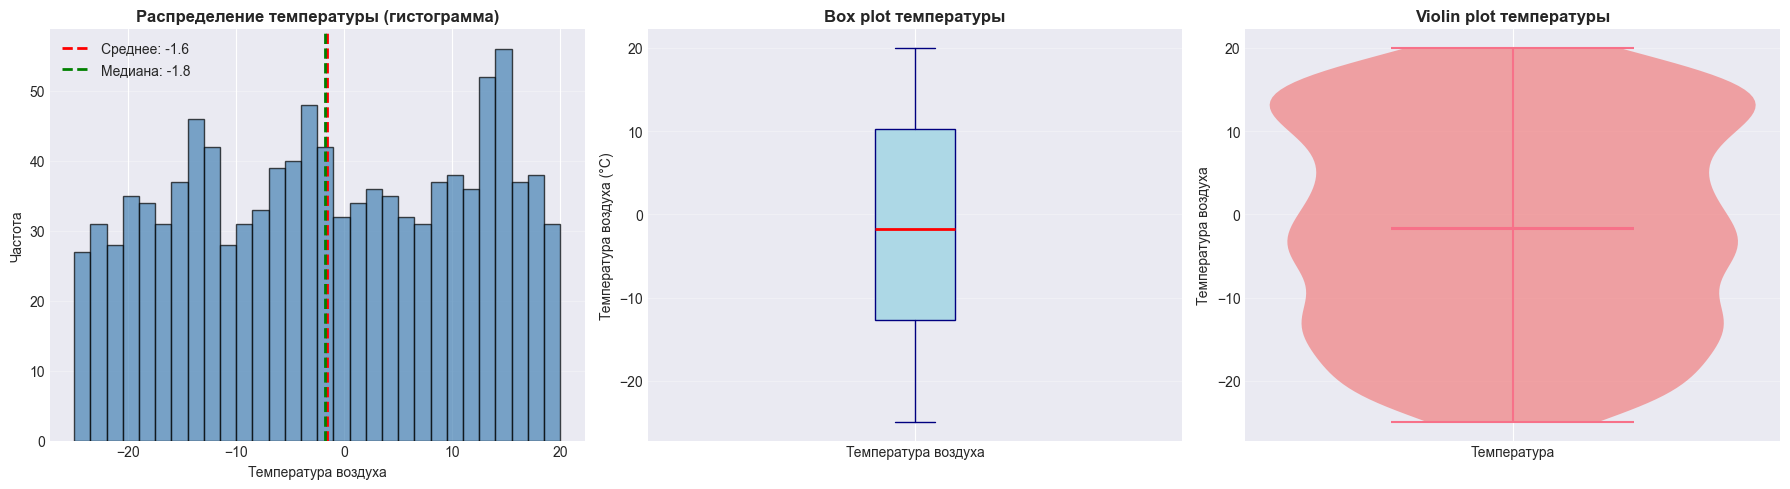


 Статистика температуры:
Среднее: -1.61
Медиана: -1.77
Стандартное отклонение: 12.79
Минимум: -24.93
Максимум: 19.98
Пропущено значений: 3 (0.3%)


In [11]:
#Анализ распределения температуры
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Гистограмма
axes[0].hist(df['Температура воздуха (°C)'].dropna(), bins = 30, color = 'steelblue', edgecolor = 'black', alpha = 0.7)
axes[0].set_xlabel('Температура воздуха')
axes[0].set_ylabel('Частота')

axes[0].set_title('Распределение температуры (гистограмма)', fontsize = 12, fontweight = 'bold')
axes[0].axvline(df['Температура воздуха (°C)'].mean(), color = 'red', linestyle = '--', linewidth = 2,
                label = f'Среднее: {df["Температура воздуха (°C)"].mean():.1f}' )
axes[0].axvline(df['Температура воздуха (°C)'].median(), color = 'green', linestyle = '--', linewidth = 2,
                label = f'Медиана: {df["Температура воздуха (°C)"].median():.1f}' )
axes[0].legend()
axes[0].grid(axis = 'y', alpha = 0.3)

#Box plot
box = axes[1].boxplot(df['Температура воздуха (°C)'].dropna(), vert = True, patch_artist = True,
                      boxprops = dict(facecolor = 'lightblue', color = 'navy'),
                      whiskerprops = dict(color = 'navy'),
                      capprops = dict(color = 'navy'),
                      medianprops = dict(color = 'red', linewidth = 2))
axes[1].set_ylabel('Температура воздуха (°C)')
axes[1].set_title('Box plot температуры', fontsize = 12, fontweight = 'bold')
axes[1].set_xticklabels(['Температура воздуха'])
axes[1].grid(axis = 'y', alpha = 0.3)

#Violin plot
parts = axes[2].violinplot([df['Температура воздуха (°C)'].dropna()], positions = [1], showmeans = True, showmedians = True)
for pc in parts['bodies']:
  pc.set_facecolor('lightcoral')
  pc.set_alpha(0.7)

axes[2].set_ylabel('Температура воздуха')
axes[2].set_title('Violin plot температуры', fontsize = 12, fontweight = "bold")
axes[2].set_xticks([1])
axes[2].set_xticklabels(['Температура'])
axes[2].grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

print(f"\n Статистика температуры:")
print(f"Среднее: {df['Температура воздуха (°C)'].mean():.2f}")
print(f"Медиана: {df['Температура воздуха (°C)'].median():.2f}")
print(f"Стандартное отклонение: {df['Температура воздуха (°C)'].std():.2f}")
print(f"Минимум: {df['Температура воздуха (°C)'].min():.2f}")
print(f"Максимум: {df['Температура воздуха (°C)'].max():.2f}")
print(f"Пропущено значений: {df['Температура воздуха (°C)'].isna().sum()} ({df['Температура воздуха (°C)'].isna().sum()/len(df)*100:.1f}%)")






1. **Гистограмма** дает мне понять, что распределение температуры полимодальное (несколько выраженных пиков: -15, -4 и +15.
2. **Box plot** показывает мне медиану (красную линию в центре), квартили (границы коробки, 25% и 75% процентили); выбросов и необычных значений не обнаружено.
3. **Violin plot** объединяет box plot с распределением плотности и показывает, где концентрируется большинство значений

<h3> Инсайт </h3>

Значения среднего и медианы очень близки друг к другу. По Violin plot заметно, что если рассматривать данные по сезонам, то в каждом из них было бы нормальное распределение температуры. (Три характерных расширения на графике)

<h4>4.2 Анализ целевой переменной: Количество особей

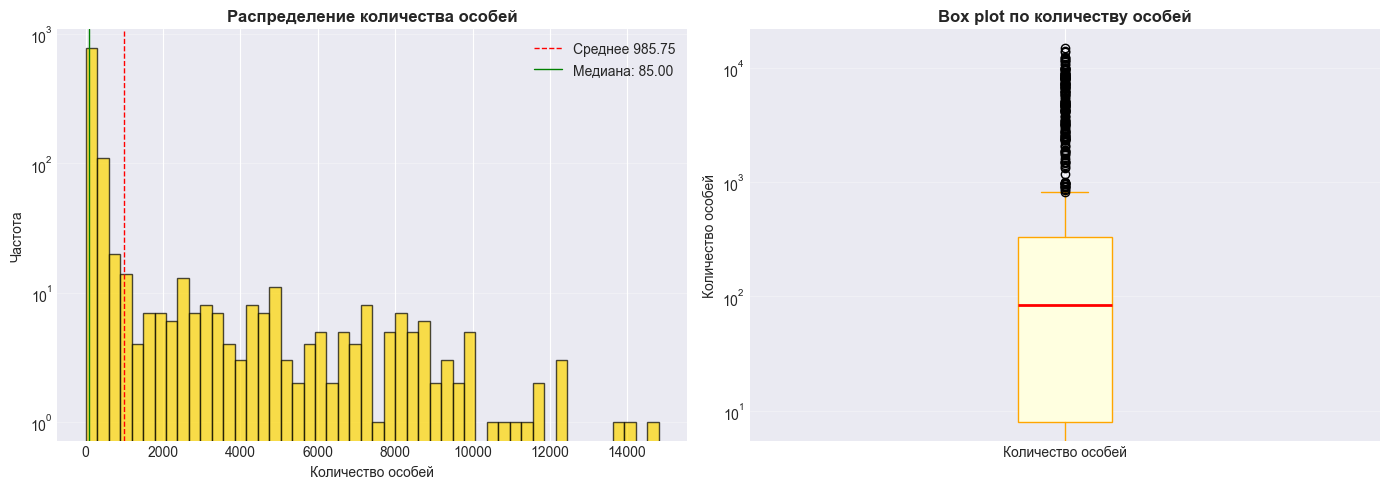


 Статистика количеств особей:
Среднее: 985.75
Медиана: $85.00
Минимум: $0.00
Максимум: $14817.00
Особи с численностью в 0: 2


In [12]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].hist(df['Количество особей'], bins = 50, color = 'gold', edgecolor = 'black', alpha = 0.7)
axes[0].set_xlabel('Количество особей')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение количества особей', fontsize = 12, fontweight = 'bold')
axes[0].axvline(df['Количество особей'].mean(), color = 'red', linestyle = '--', linewidth = 1, label = f'Среднее {df["Количество особей"].mean():.2f}')
#  От себя добавил вертикальную линию, медиану
axes[0].axvline(df['Количество особей'].median(), color='green', linestyle='-', linewidth=1, label=f'Медиана: {df["Количество особей"].median():.2f}')
#  ЮЛИЯ ВИКТОРОВНА!!! у вас в вашем titanic_EDA примере написано про логарифмическое скалирование, но в коде оно не применено.
#  А я применил, чтобы все нормально было видно и потому что я четкий пацан
#  + утоньшил линии медианы и среднего в два раза, так как столбцы гистограммы и без того тонкие, для баланса так сказать
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(axis='y', alpha = 0.3)

# Box plot
box = axes[1].boxplot(df['Количество особей'].dropna(), vert = True, patch_artist = True,
                      boxprops = dict(facecolor = 'lightyellow', color = 'orange'),
                      whiskerprops = dict(color = 'orange'),
                      capprops = dict(color = 'orange'),
                      medianprops = dict(color = 'red', linewidth = 2))
# Скалирование, много выбросов
axes[1].set_yscale('log', nonpositive='clip')
axes[1].set_ylabel('Количество особей')
axes[1].set_title('Box plot по количеству особей', fontsize = 12, fontweight = 'bold')
axes[1].set_xticklabels(['Количество особей'])
axes[1].grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

print(f"\n Статистика количеств особей:")
print(f"Среднее: {df['Количество особей'].mean():.2f}")
print(f"Медиана: ${df['Количество особей'].median():.2f}")
print(f"Минимум: ${df['Количество особей'].min():.2f}")
print(f"Максимум: ${df['Количество особей'].max():.2f}")
print(f"Особи с численностью в 0: {(df['Количество особей'] == 0).sum()}")





На **гистограмме** наблюдается ассиметричное скошенное вправо распределение. По **Box plot** видно, что выбросов очень много.
В целом по распределению заметно, что очень много видов животных с низкой численностью особей. Что в целом нормально для природы (согласно закону Ципфа). *Возможно, количество особей может быть связано с температурой среды обитания.*

<h3>4.3 Анализ переменной: Тип</h3>

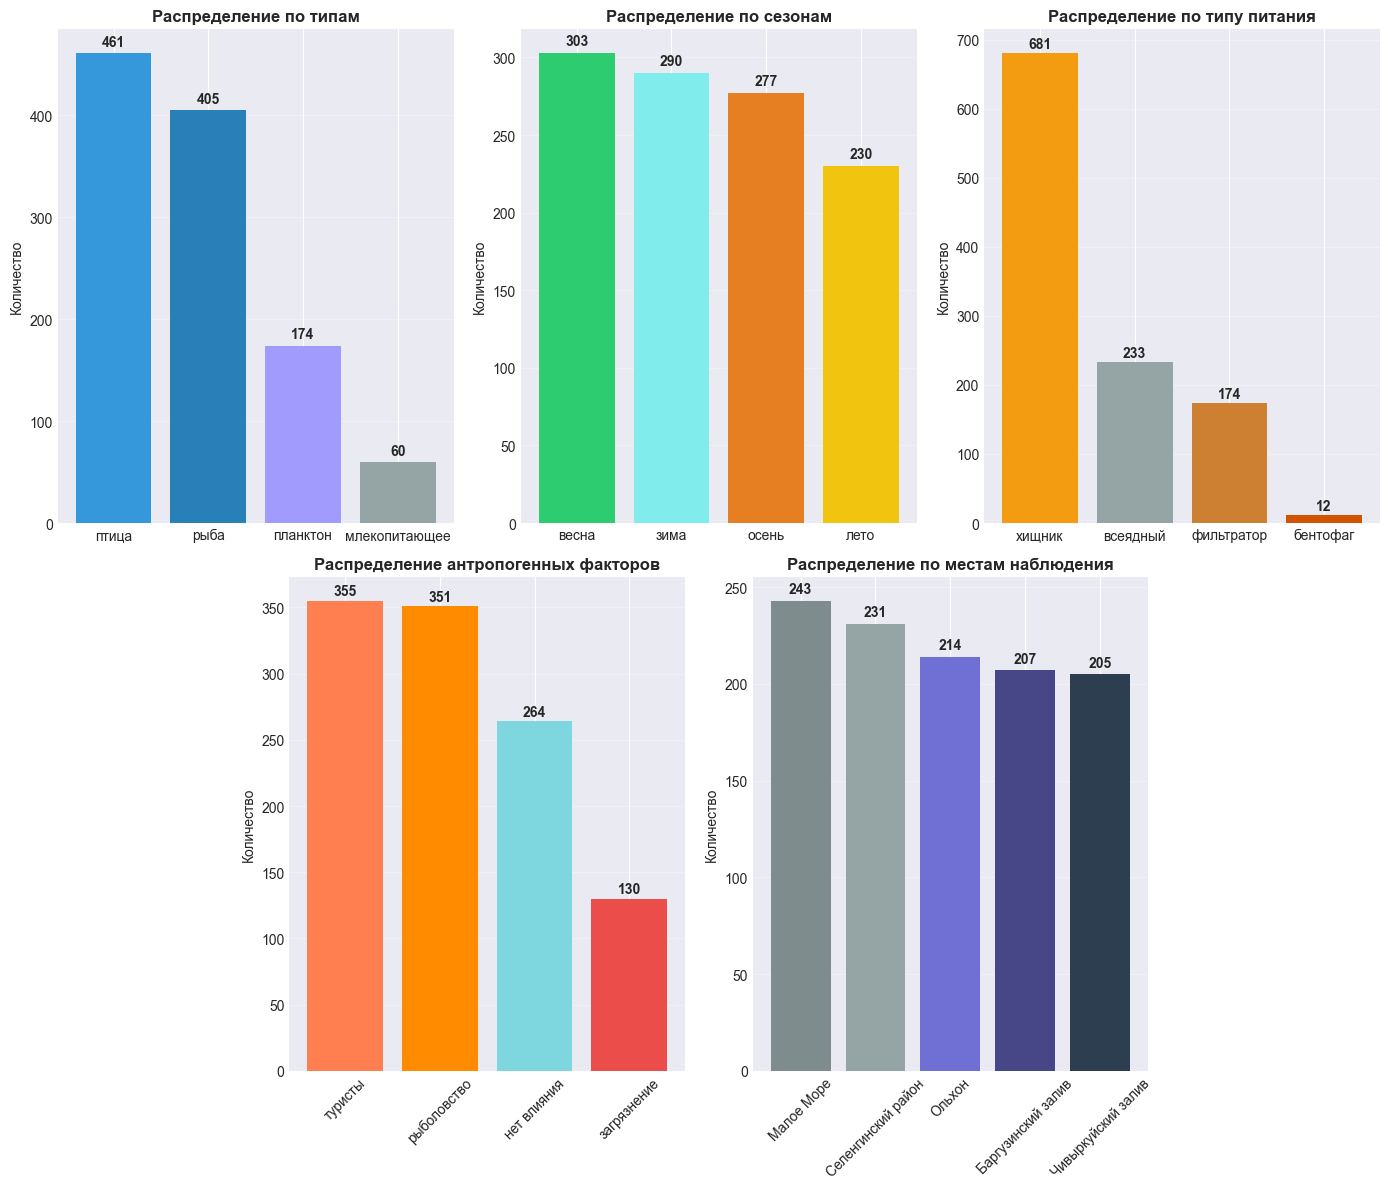


Статистика категориальных переменных:


Тип
птица            461
рыба             405
планктон         174
млекопитающее     60
Name: count, dtype: int64


Сезон
весна    303
зима     290
осень    276
лето     229
Лето       1
Осень      1
Name: count, dtype: int64


Тип питания
хищник        681
всеядный      233
фильтратор    174
бентофаг       12
Name: count, dtype: int64


Антропогенный фактор
туристы        355
рыболовство    351
нет влияния    263
загрязнение    130
НЕТ              1
Name: count, dtype: int64


Место наблюдения
Малое Море            243
Селенгинский район    231
Ольхон                214
Баргузинский залив    207
Чивыркуйский залив    205
Name: count, dtype: int64


In [13]:
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 6)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])


# Тип
types_count = df['Тип'].value_counts()
ax1.bar(types_count.index, types_count.values,
                color=['#3498db', '#2980b9', '#a29bfe', '#95a5a6'])
ax1.set_ylabel('Количество')
ax1.set_title('Распределение по типам', fontsize = 12, fontweight = 'bold')
ax1.grid(axis = 'y', alpha = 0.3)

for i, v in enumerate(types_count.values):
    ax1.text(i, v + 7, str(v), ha = 'center', fontweight = 'bold')


# Сезон
season_counts = df['Сезон'].str.lower().value_counts() 
# str.lower() потому что данные грязные ( разные сезоны "Лето" и "лето" для примера)
ax2.bar(season_counts.index, season_counts.values,
               color=['#2ecc71', '#81ecec', '#e67e22', '#f1c40f'])
ax2.set_ylabel('Количество')
ax2.set_title('Распределение по сезонам', fontsize = 12, fontweight = 'bold')
ax2.grid(axis = 'y', alpha = 0.3)
for i, v in enumerate(season_counts.values):
    ax2.text(i, v + 5, str(v), ha = 'center', fontweight = 'bold')


# Тип питания
nutrition_type_counts = df['Тип питания'].value_counts()
ax3.bar(nutrition_type_counts.index, nutrition_type_counts.values,
               color=['#f39c12', '#95a5a6', '#cd7f32', '#d35400'])
ax3.set_ylabel('Количество')
ax3.set_title('Распределение по типу питания', fontsize = 12, fontweight = 'bold')
ax3.grid(axis = 'y', alpha = 0.3)
for i, v in enumerate(nutrition_type_counts.values):
    ax3.text(i, v + 7, str(v), ha = 'center', fontweight = 'bold')


# Антропогенный фактор
tmp_col = df['Антропогенный фактор'].replace('НЕТ', 'нет влияния') # Снова грязь в данных lol
anthropogenic_factor_counts = tmp_col.str.lower().value_counts()
ax4.bar(anthropogenic_factor_counts.index,
               anthropogenic_factor_counts.values, 
               color=['#ff7f50', '#ff8c00', '#7ed6df', '#eb4d4b', '#badc58'])
ax4.set_ylabel('Количество')
ax4.set_title('Распределение антропогенных факторов', 
                     fontsize = 12, fontweight = 'bold')
ax4.grid(axis = 'y', alpha = 0.3)
ax4.tick_params(axis='x', rotation=45) 
for i, v in enumerate(anthropogenic_factor_counts.values):
    ax4.text(i, v + 4, str(v), ha = 'center', fontweight = 'bold')


# Место наблюдения
place_counts = df['Место наблюдения'].value_counts()
ax5.bar(place_counts.index, place_counts.values, 
               color=['#7f8c8d', '#95a5a6', '#706fd3', '#474787', '#2c3e50'])
ax5.set_ylabel('Количество')
ax5.set_title('Распределение по местам наблюдения', 
                     fontsize = 12, fontweight = 'bold')
ax5.grid(axis = 'y', alpha = 0.3)
ax5.tick_params(axis='x', rotation=45) 
for i, v in enumerate(place_counts.values):
    ax5.text(i, v + 4, str(v), ha = 'center', fontweight = 'bold')

plt.tight_layout()
plt.show()

print(f"\nСтатистика категориальных переменных:")
print("\n")
print(df['Тип'].value_counts())
print("\n")
print(df['Сезон'].value_counts())
print("\n")
print(df['Тип питания'].value_counts())
print("\n")
print(df['Антропогенный фактор'].value_counts())
print("\n")
print(df['Место наблюдения'].value_counts())




#### Инсайты из категориальных переменных:

1. **Доминирующие виды:** Птицы и рыбы составляют подавляющее большинство наблюдений (свыше 850 случаев). Млекопитающие встречаются реже всего (всего 60), что делает их наиболее редким объектом в данной выборке.
2. **Сезонность:** Наблюдения распределены по временам года довольно равномерно, однако весна и зима лидируют. Это может говорить о том, что активность видов или экспедиций в холодные и переходные периоды чуть выше, чем летом.
3. **Пищевая цепочка:** В экосистеме наблюдается колоссальный перекос в сторону **хищников** (681 наблюдение). Это довольно необычно для стабильной пирамиды и может указывать либо на специфику сбора данных (считали только крупных/заметных), либо на то, что это экосистема с высокой концентрацией вторичных консументов.
4. **Антропогенное воздействие:** Туризм и рыболовство — главные факторы давления на среду, идущие «ноздря в ноздрю». При этом более чем в 260 случаях влияния человека не обнаружено, что говорит о наличии заповедных или труднодоступных зон.
5. **География:** Наблюдения распределены по Байкалу очень сбалансировано. **Малое Море** лидирует, но отрыв от Чивыркуйского залива минимален. Это качественная выборка, охватывающая все ключевые локации региона примерно в равных долях.


**Новые вопросы для исследования:**

* **Связь питания и локации:** В каких именно местах (например, Ольхон vs Селенгинский район) чаще встречаются хищники?
* **Влияние человека на виды:** Как распределяются антропогенные факторы по типам животных? (Например, страдают ли птицы от туристов больше, чем рыбы от рыболовства?)
* **Сезонная миграция:** Меняется ли состав видов (птицы/рыбы) в зависимости от сезона?
* **Экологический риск:** В каких точках наблюдения чаще всего фиксируется «загрязнение», и какие типы животных там преобладают?

---

<h2> 5. Анализ пропусков данных
<h4> Визуализация пропусков

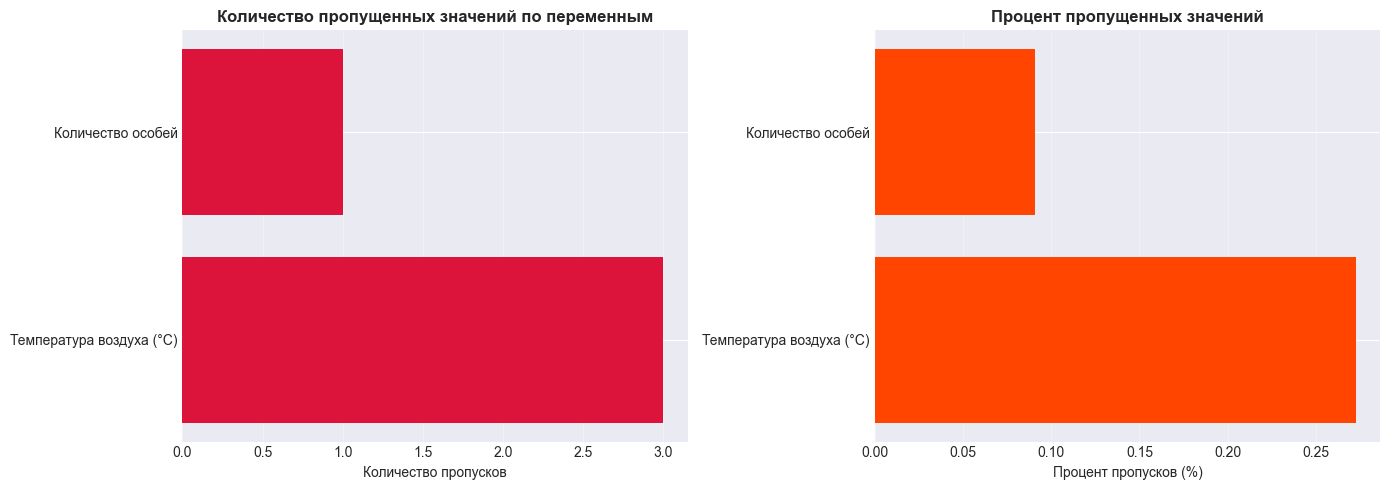


Cтатистика пропусков:


,Пропусков,Процент
Температура воздуха (°C),3,0.272727
Количество особей,1,0.090909


In [14]:
# Анализ пропущенных значений
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропусков': missing,
    'Процент': missing_percent
}).sort_values('Пропусков', ascending=False)

missing_df = missing_df[missing_df['Пропусков'] > 0]

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Bar chart пропусков
axes[0].barh(missing_df.index, missing_df['Пропусков'], color = 'crimson')
axes[0].set_xlabel('Количество пропусков')
axes[0].set_title('Количество пропущенных значений по переменным',
                   fontsize = 12, fontweight = 'bold')
axes[0].grid(axis = 'x', alpha = 0.3)

# Процент пропусков
axes[1].barh(missing_df.index, missing_df['Процент'], color = 'orangered')
axes[1].set_xlabel('Процент пропусков (%)')
axes[1].set_title('Процент пропущенных значений', 
                  fontsize = 12, fontweight = 'bold')
axes[1].grid(axis = 'x', alpha = 0.3)

plt.tight_layout()
plt.show()

print("\nCтатистика пропусков:")
display(missing_df)

<h4>Наблюдения</h4>
Количество пропусков незначительно, их можно заполнить модой (самым частым знаачением)

<h4>Исследование паттернов пропусков</h4>

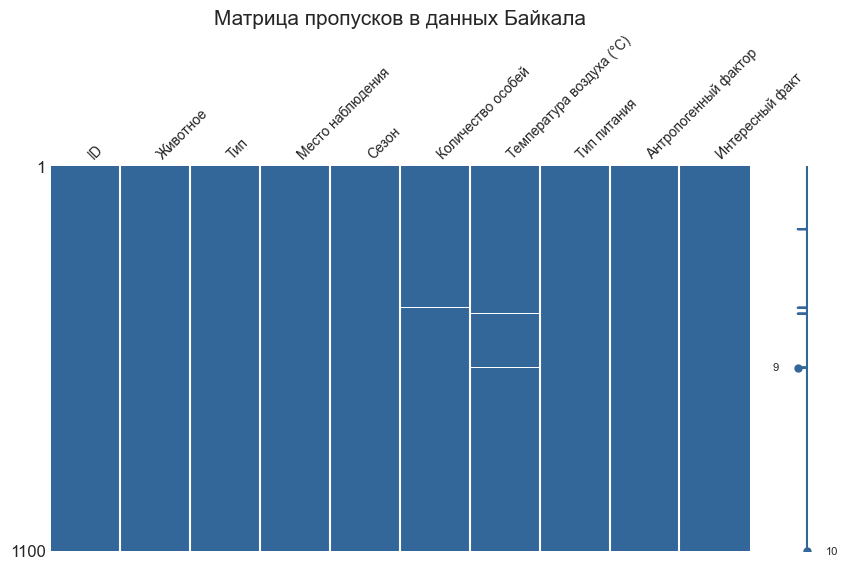

Строки с пропусками:


,ID,Животное,Тип,Место наблюдения,Сезон,Количество особей,Температура воздуха (°C),Тип питания,Антропогенный фактор,Интересный факт
180,181,Чайка,птица,Ольхон,весна,15.0,NaN,хищник,туристы,"Гнездится колониями на скалах, питается рыбой"
404,405,Чайка,птица,Ольхон,лето,NaN,18.594933,хищник,рыболовство,"Гнездится колониями на скалах, питается рыбой"
421,422,Чайка,птица,Чивыркуйский залив,лето,24.0,NaN,хищник,туристы,"Гнездится колониями на скалах, питается рыбой"
575,576,Чайка,птица,Баргузинский залив,осень,18.0,NaN,хищник,туристы,"Гнездится колониями на скалах, питается рыбой"


In [ ]:
# Матрица пропусков
msno.matrix(df, figsize=(10, 5), fontsize=10, color=(0.2, 0.4, 0.6))
plt.title('Матрица пропусков в данных Байкала', fontsize=15)
plt.show()

missing_rows = df[df.isnull().any(axis=1)]
print("Строки с пропусками:")
display(missing_rows)



<h4>Наблюдения по пропускам</h4>

Пропущенных значений слишком мало. Осмотрел локально. Все пропуски значений (**температура** и количество **особей**) возникли у животных **Чайка**. Возможно, это связано с тем, что тяжело вести их подсчет, потому что они летают и их много, или датчики не успевают зафиксировать температуру.

Тип пропусков - **MAR** (Missing At Random), так как они зависят от переменной `Чайка`

<h2>6. Двумерный анализ (Bivarite Analaysis)</h3>

Исследование взаимосвязей переменных


<h3>6.1 Количество особей по сезону</h4>


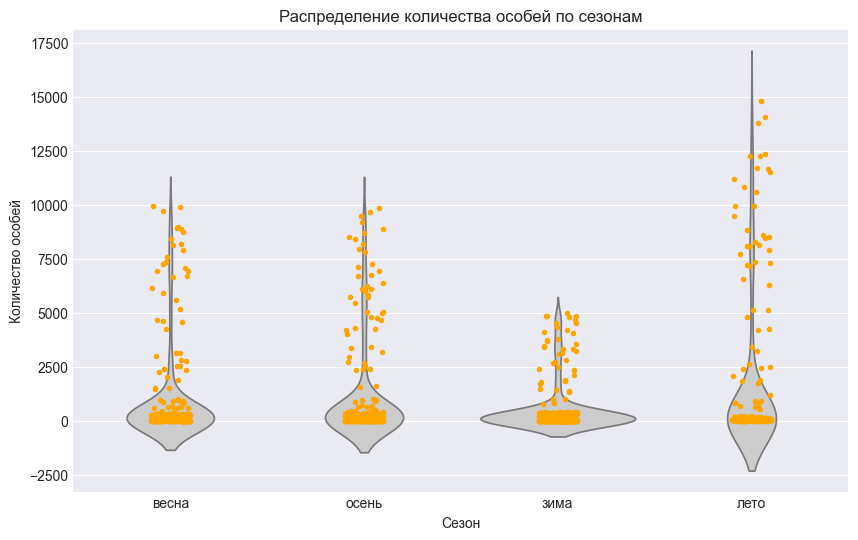

In [19]:
plt.figure(figsize=(10, 6))
df['Сезон'] = df['Сезон'].str.lower()
sns.violinplot(data=df, x='Сезон', y='Количество особей', inner=None, color=".8")
sns.stripplot(data=df, x='Сезон', y='Количество особей', size=4, jitter=True, color="orange")
plt.title('Распределение количества особей по сезонам')
plt.xlabel('Сезон')
plt.ylabel('Количество особей')
plt.show()

- Лето является сезоном с самым высоким потенциальным количеством особей. Здесь наблюдается самый высокий «хвост» распределения (достигает почти 17 500).  Концентрация высоких значений (оранжевые точки выше 10 000) значительно плотнее, чем в другие периоды.

- Зима демонстрирует самые низкие показатели. Максимальные значения едва превышают 5 000. Само «тело» графика (серая область) более приплюснутое, что говорит о низкой вариативности и стабильно малом количестве особей в этот период.

- Распределения для весны и осени очень похожи между собой: Оба имеют медиану, близкую к нулю (широкая часть внизу). Оба показывают умеренное количество выбросов или редких наблюдений в диапазоне от 2 500 до 10 000.

- Для всех сезонов характерно смещение распределения вниз: Основная масса данных (самая широкая часть «скрипки») сосредоточена около нуля. Это значит, что в большинстве случаев количество особей невелико.

- Наличие длинных узких «горлышек» вверх указывает на то, что высокие показатели встречаются редко и являются скорее исключением (выбросами), чем правилом.

<h3>6.2 Количество особей в зависимости от температуры</h4>

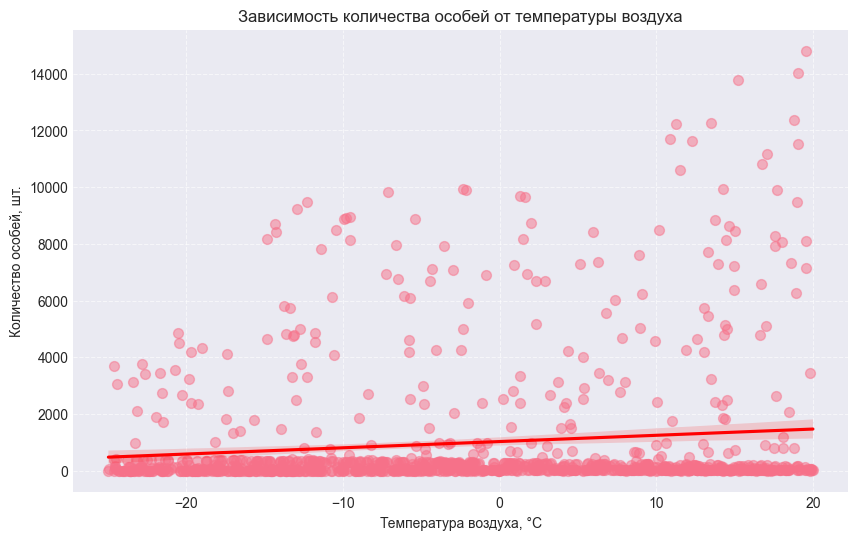

In [22]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df , x='Температура воздуха (°C)', y='Количество особей',
            scatter_kws = {'alpha' : 0.5, 's' : 50},
            line_kws={'color': "red"}) 

plt.title('Зависимость количества особей от температуры воздуха')
plt.xlabel('Температура воздуха, °C')
plt.ylabel('Количество особей, шт.')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- Положительная корреляция: Красная линия регрессии имеет восходящий тренд, что указывает на слабую прямую зависимость: с ростом температуры количество особей в среднем увеличивается.

- Увеличение дисперсии: При низких температурах (ниже -10°C) значения кучно сосредоточены около нуля. С потеплением (выше 10°C) разброс данных резко возрастает, и появляются максимальные значения (до 14 000+ шт.).

- Концентрация данных: Подавляющее большинство точек при любой температуре находится в нижней части графика (близко к 0). Это говорит о том, что массовые скопления особей — явление редкое, но более вероятное в теплую погоду.

- Температурный диапазон: Данные охватывают диапазон примерно от -25°C до +20°C.

<h3> 6.3 Количетсво особей по видам животных

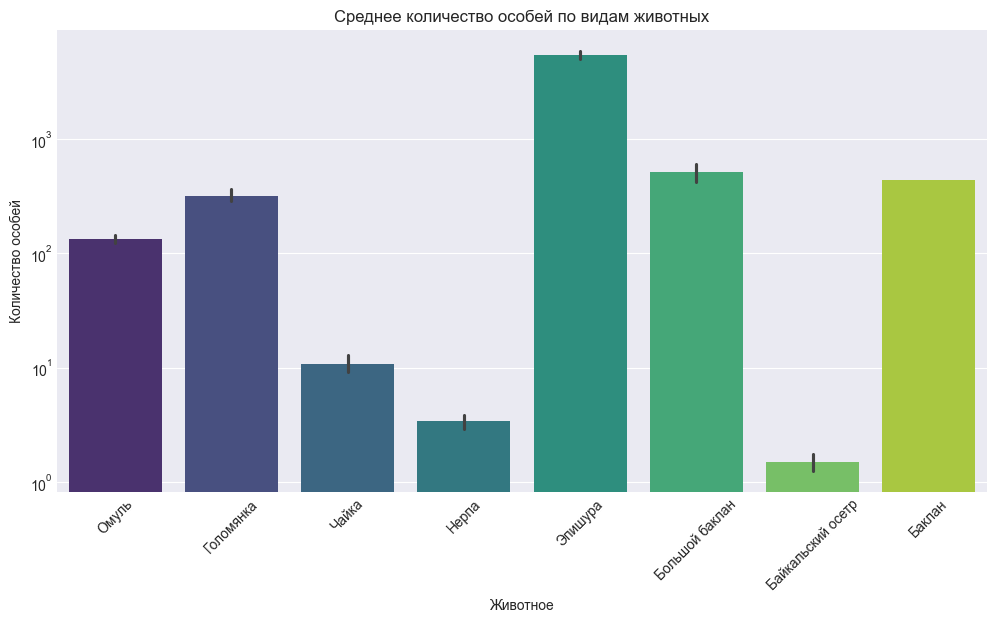

In [ ]:
plt.figure(figsize=(12, 6))

g = sns.barplot(data=df, x='Животное', y='Количество особей', palette = 'viridis',)
g.set_yscale("log")

plt.title('Среднее количество особей по видам животных')
plt.xticks(rotation=45)
plt.show()


- Вид Эпишура имеет самое высокое среднее количество особей (превышает $10^3$, т.е. более 1000 шт.).
- Далее следуют Большой баклан, Баклан и Голомянка, чьи средние показатели находятся в диапазоне от 100 до 1000 особей. 
- Самая низкая численность наблюдается у Байкальского осетра (около 1-2 особей) и Нерпы (менее 10).
- Короткие черные линии («усы») на вершинах столбцов указывают на низкую погрешность или малую вариативность средних значений для большинства видов.

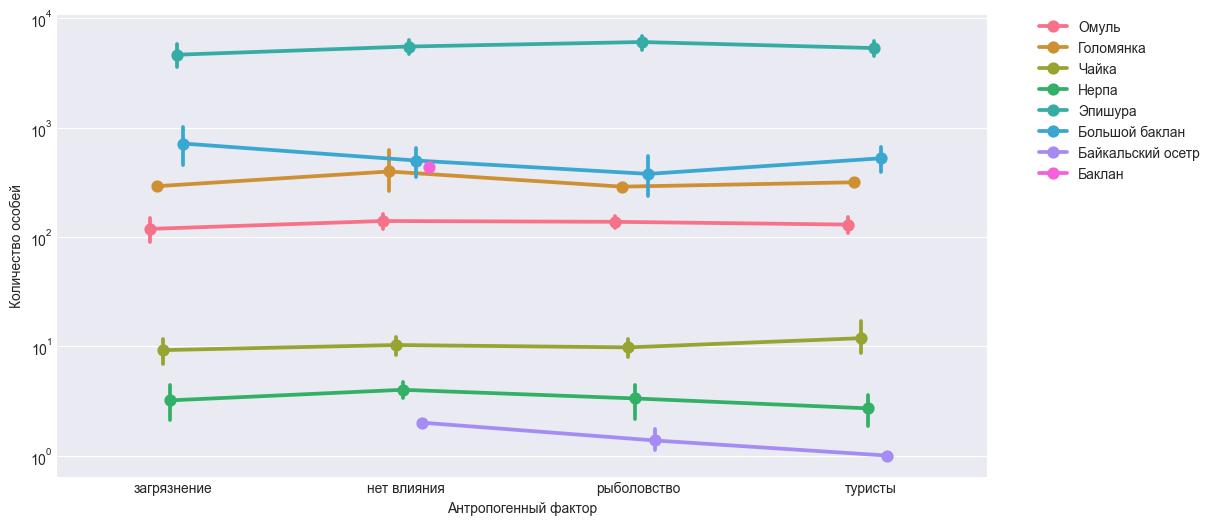

In [ ]:
plt.figure(figsize=(12, 6))
df['Антропогенный фактор'] = df['Антропогенный фактор'].replace('НЕТ', 'нет влияния')

sns.pointplot(data=df, x='Антропогенный фактор', y='Количество особей', hue='Животное', dodge=True)
plt.yscale('log') 

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

- Численность самого массового вида, Эпишуры, остается стабильно высокой (около $10^3$–$10^4$) вне зависимости от типа воздействия.
- Байкальский осетр демонстрирует явное снижение численности при переходе от зон «нет влияния» к зонам с рыболовством и туристами, достигая своего минимума.
- Численность Большого баклана заметно выше в зонах загрязнения по сравнению с зонами рыболовства, что может быть связано с перераспределением кормовой базы.
- Для большинства видов (Омуль, Голомянка, Чайка, Нерпа) графики выглядят практически горизонтальными линиями. Это говорит о том, что в данных масштабах антропогенные факторы не вызывают катастрофических изменений их средней численности.

<h3>6.4 Корреляционный анализ числовых переменных</h4>

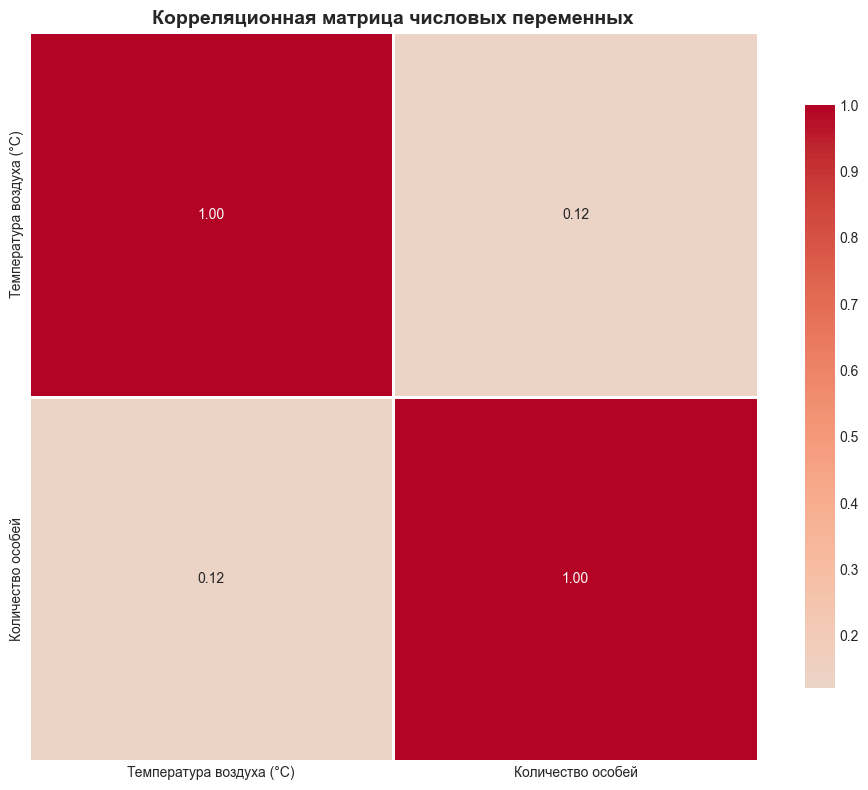


 Корреляция переменных с количеством особей:
Количество особей           1.000000
Температура воздуха (°C)    0.120992
Name: Количество особей, dtype: float64


In [41]:
numeric_cols = ['Температура воздуха (°C)', 'Количество особей']
correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt = '.2f', cmap = 'coolwarm',
            center = 0, square = True, linewidths=1, cbar_kws = {"shrink": 0.8},
            ax = ax)
ax.set_title('Корреляционная матрица числовых переменных', fontsize = 14,
              fontweight = 'bold')
plt.tight_layout()
plt.show()

print("\n Корреляция переменных с количеством особей:")
population_corr = correlation_matrix['Количество особей'].sort_values(ascending = False)
print(population_corr)

У нас всего 2 числовых значения. Коэфициент корреляции между ними - 0.12, что говорит о слабой линейной зависимости. Температура — это фоновое условие, которое позволяет численности вырасти (создает потенциал), но не гарантирует этого.


<h4> Вывод </h4>
Мы увидели, что численность животных на Байкале сильнее всего зависит от сезона и температуры (природные факторы), в то время как антропогенное воздействие на текущий момент сильнее всего сказывается на самых уязвимых видах, таких как осетр.

<h2>7. Многомерный анализ (Multivariate Analysis)</h3>

<h3>7.1 Facet Grid: Зависимость численности и температуры по видам и типам питания</h3>

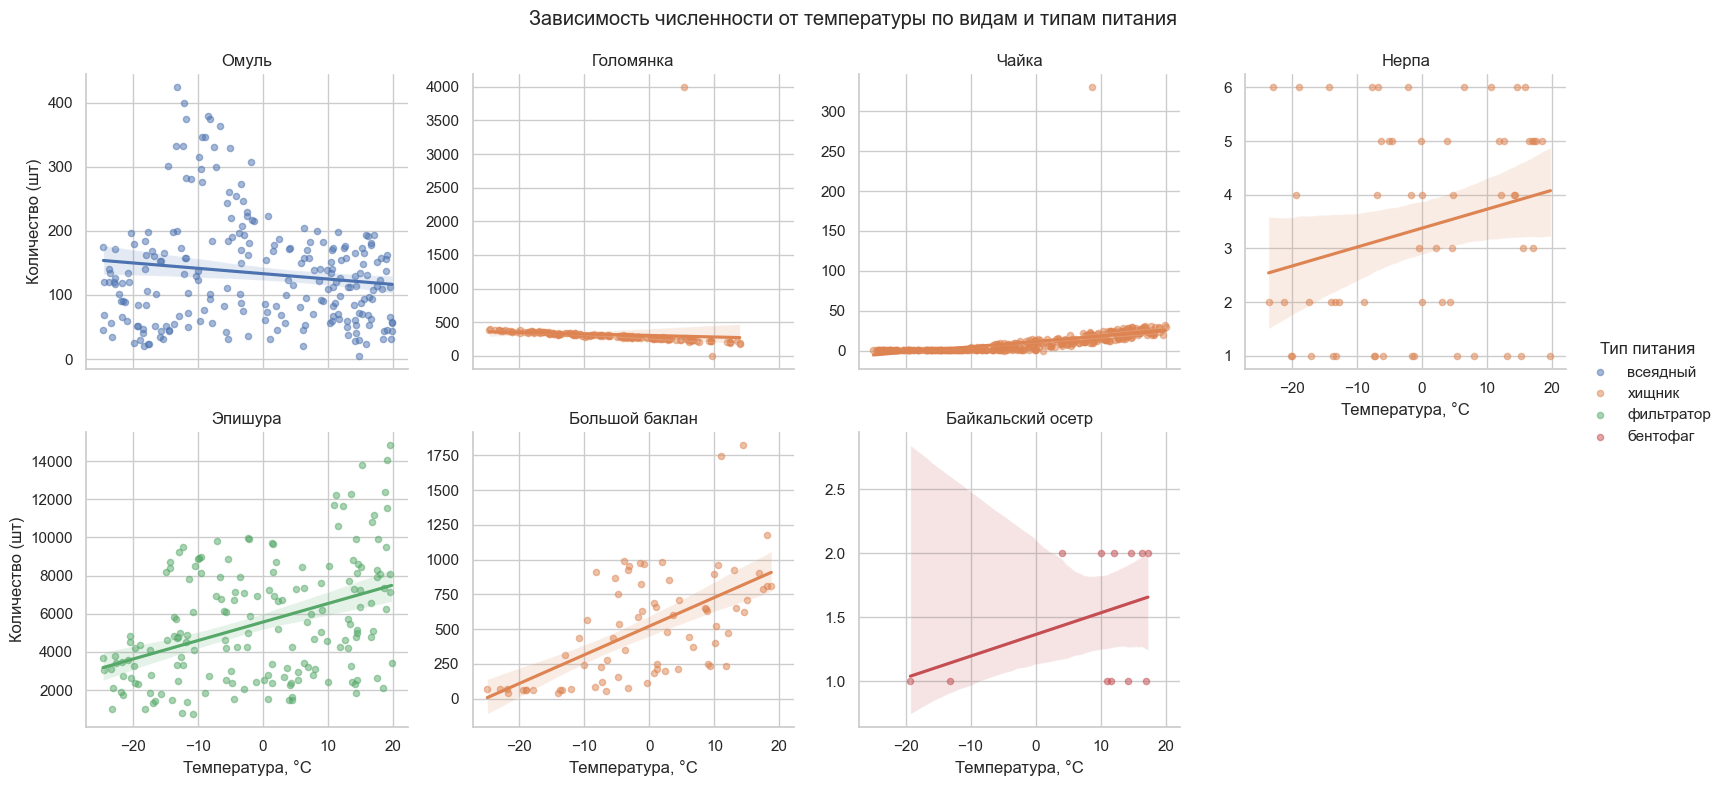

In [ ]:

sns.set_theme(style="whitegrid")

df['Животное'] = df['Животное'].replace('Баклан', 'Большой баклан')
g = sns.FacetGrid(df, col="Животное", hue="Тип питания", 
                  col_wrap=4, height=4, sharey=False)

g.map(sns.regplot, "Температура воздуха (°C)", "Количество особей", 
      scatter_kws={'alpha':0.5, 's':20})

g.add_legend(title="Тип питания")
g.set_titles("{col_name}")
g.set_axis_labels("Температура, °C", "Количество (шт)")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Зависимость численности от температуры по видам и типам питания')

plt.show()

Анализ выявил, что температурный фактор является определяющим для Нерпы, Эпишуры, Большого баклана и Байкальского осетра. У остальных животных численностьь зависит от типа питания. У Бакланов, Осетров и Голомянок численность предсказывается очень легко, т.к. точки близко прижаты к линии.

Видны аномалии у видов: **Байкальский осетр** и **нерпа**

<h2> 8. Выявление выбросов и аномалий </h2>

<h3>8.1 Поиск выбросов в числе особей </h3>



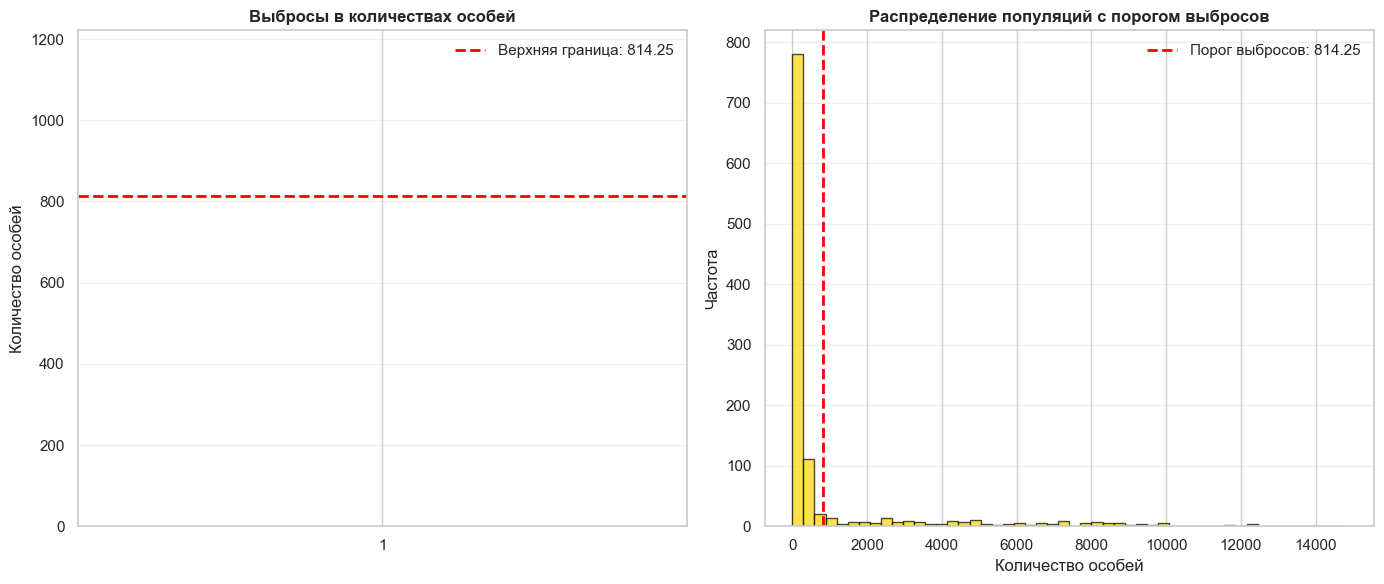


 Найдено 190 выбросов в численностях особей
Нижняя граница: -475.75
Верхняя граница: 814.25


In [ ]:
#  IQR метод
Q1 = df['Количество особей'].quantile(0.25)
Q3 = df['Количество особей'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Количество особей'] < lower_bound) | (df['Количество особей'] > upper_bound)]

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

axes[0].boxplot(df['Количество особей'], vert = True, patch_artist = True,
                boxprops = dict(facecolor = 'lightyellow', color = 'orange'),
                whiskerprops = dict(color = 'orange'),
                capprops = dict(color = 'orange'),
                medianprops = dict(color = 'red', linewidth = 2),
                flierprops = dict(marker = 'o', markerfacecolor = 'red', markersize = 8,
                                  linestyle = 'none'))
axes[0].axhline(y = upper_bound, color = 'red', linestyle = '--',
               linewidth = 2, label = f'Верхняя граница: {upper_bound:.2f}')
axes[0].set_ylabel('Количество особей')
axes[0].set_title('Выбросы в количествах особей', fontsize = 12, fontweight = 'bold')
axes[0].legend()
axes[0].grid(axis = 'y', alpha = 0.3)
axes[0].set_ylim(0, upper_bound * 1.5)


#  Гистограмма с отметкой выбросов
axes[1].hist(df['Количество особей'], bins=50, color='gold', edgecolor='black', alpha=0.7)
axes[1].axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Порог выбросов: {upper_bound:.2f}')
axes[1].set_xlabel('Количество особей')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение популяций с порогом выбросов', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Найдено {len(outliers)} выбросов в численностях особей")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")


-  Количество: Выявлено 190 выбросов. Это довольно много (визуально около 15–20% данных), что сигнализирует о неоднородности выборки.

- Масштаб: Верхняя граница установлена на уровне 814.25, однако максимальные значения достигают 14 000. Это означает, что крупнейшие популяции превышают порог нормальности более чем в 17 раз.

- Природа выбросов: Скорее всего, это не ошибки измерения, а реальные уникальные объекты (доминирующие виды в экосистеме).

<h3> 8.2 Поиск аномалий в температуре

In [59]:
# Проверка на аномалии в температуре
print("Статистика температуры:")
print(f"Минимум: {df['Температура воздуха (°C)'].min()}")
print(f"Максимум: {df['Температура воздуха (°C)'].max()}")
print(f"\n Обитатели самых теплых мест:")
print(df.nlargest(5, 'Температура воздуха (°C)')[['Животное', 'Место наблюдения','Температура воздуха (°C)', 'Количество особей']])
print(f"\n Обитатели самых холодгых мест:")
print(df.nsmallest(5, 'Температура воздуха (°C)')[['Животное', 'Место наблюдения', 'Температура воздуха (°C)', 'Количество особей']])


Статистика температуры:
Минимум: -24.9328078462
Максимум: 19.9813011592

 Обитатели самых теплых мест:
    Животное    Место наблюдения  Температура воздуха (°C)  Количество особей
506    Чайка          Малое Море                 19.981301               30.0
733    Чайка          Малое Море                 19.948942               32.0
915    Омуль  Селенгинский район                 19.886102               56.0
302    Омуль          Малое Море                 19.857676               43.0
606  Эпишура              Ольхон                 19.777628             3428.0

 Обитатели самых холодгых мест:
            Животное    Место наблюдения  Температура воздуха (°C)  Количество особей
43             Чайка  Селенгинский район                -24.932808                1.0
211   Большой баклан          Малое Море                -24.909988               69.0
949          Эпишура          Малое Море                -24.595679             3691.0
1009       Голомянка  Чивыркуйский залив            

Все значения в разумных пределах. Аномалий нет

<h2> 8. Результаты EDA и дальнейшие шаги</h2>

В ходе выполнения вычислительного эссе был проведен разведочный анализ данных (EDA), который позволил глубже понять структуру популяции и условия обитания фауны озера.

 Что мы узнали о данных:
#### 1. Состояние данных:
- Объем: Датасет содержит 1100 записей и 10 признаков.

- Пропуски: Данные очень чистые. Пропущено всего 0,1% значений в столбце «Количество особей» и 0,3% в «Температура воздуха». Эти пропуски можно легко заполнить медианой или средним.

- Аномалии: Проверка температуры показала, что все значения (от -24.9°C до +19.9°C) находятся в пределах разумного для байкальского региона.

#### 2. Ключевые находки:
- Самый частый вид: Чайки являются наиболее часто встречающимся объектом наблюдения (387 записей из 1100).

- Температурный режим: Средняя температура среды обитания зафиксирована на уровне -1.6 °C.

- Антропогенное воздействие: Самым частым фактором влияния человека на животных признан туризм (355 случаев).

- Тип питания: В данных преобладают хищники (681 особь).

#### 3. Идеи для производных признаков (Feature Engineering):
- Плотность популяции: Группировка данных по «Месту наблюдения» для выявления зон с наибольшей концентрацией животных.

- Сезонная активность: Создание признака «Суровость сезона» на основе средней температуры.

- Кластеризация локаций: Объединение мест наблюдения в группы (например, «Заливы» vs «Открытый Байкал»).

- Агрегация по типу питания: Анализ соотношения хищников и всеядных в разных районах.

#### Дальнейшие шаги:
- Обработка пропусков: Заполнить единичные пустые значения в численных столбцах.

- Географический анализ: Визуализировать распределение видов по конкретным точкам (Ольхон, Чивыркуйский залив и др.).


#### Моделирование:

- Построить модель для предсказания численности популяции в зависимости от сезона и температуры.

- Классифицировать влияние антропогенных факторов на различные виды.